Saving kaggle.json to kaggle.json
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


Epoch 1: TrainAcc 0.737 ValAcc 0.868
Epoch 2: TrainAcc 0.831 ValAcc 0.923
Epoch 3: TrainAcc 0.869 ValAcc 0.934
Epoch 4: TrainAcc 0.878 ValAcc 0.936
Epoch 5: TrainAcc 0.881 ValAcc 0.934
Epoch 6: TrainAcc 0.890 ValAcc 0.920
Epoch 7: TrainAcc 0.893 ValAcc 0.926
Epoch 8: TrainAcc 0.904 ValAcc 0.943

🌱 SOIL REPORT:
              precision    recall  f1-score   support

        Clay       0.00      0.00      0.00         0
       Sandy       0.00      0.00      0.00         0
       Loamy       0.00      0.00      0.00         0
       Black       1.00      1.00      1.00         6
         Red       0.00      0.00      0.00         0
    Alluvial       0.00      0.00      0.00         0

    accuracy                           1.00         6
   macro avg       0.17      0.17      0.17         6
weighted avg       1.00      1.00      1.00         6


🌾 CONDITION REPORT:
              precision    recall  f1-score   support

     Healthy       0.87      0.96      0.91       173
   Unhealthy   

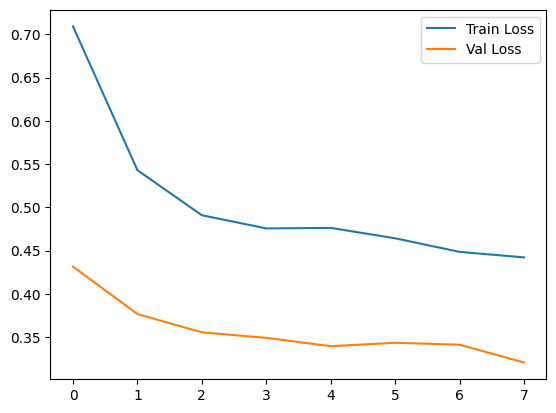

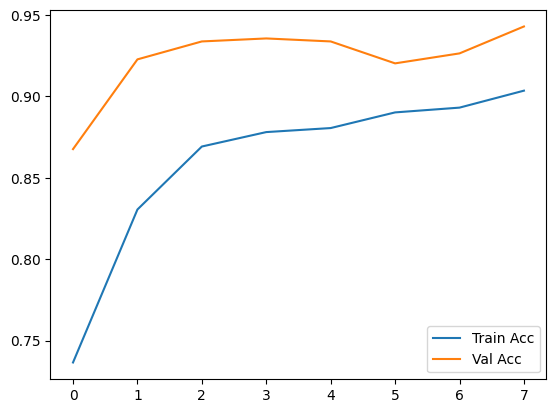

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ===================== FINAL CLEAN PIPELINE =====================

!pip -q install kaggle scikit-learn matplotlib

import os, zipfile, random, json, shutil
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# ---------------- CONFIG ----------------
CFG = {
    "soil_zip": "/content/soil-types.zip",
    "plant_zip": "/content/plantdisease.zip",
    "soil_dir": "/content/soil_dataset",
    "plant_dir": "/content/plant_dataset",
    "epochs": 8,
    "batch_size": 16,
    "lr": 1e-4
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- KAGGLE ----------------
from google.colab import files
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

os.system("kaggle datasets download -d prasanshasatpathy/soil-types -p /content/")
os.system("kaggle datasets download -d emmarex/plantdisease -p /content/")

# ---------------- EXTRACT ----------------
os.makedirs(CFG["soil_dir"], exist_ok=True)
os.makedirs(CFG["plant_dir"], exist_ok=True)

with zipfile.ZipFile(CFG["soil_zip"], 'r') as z:
    z.extractall(CFG["soil_dir"])
with zipfile.ZipFile(CFG["plant_zip"], 'r') as z:
    z.extractall(CFG["plant_dir"])

# ---------------- LABELS ----------------
SOIL_MAP = {"clay":0,"sandy":1,"loamy":2,"black":3,"red":4,"alluvial":5}
SOIL_NAMES = ["Clay","Sandy","Loamy","Black","Red","Alluvial"]
COND_NAMES = ["Healthy","Unhealthy"]
DIS_NAMES  = ["Healthy","Diseased"]
IGNORE = -1

# ---------------- BUILD DATA ----------------
def get_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder) if f.lower().endswith((".jpg",".png",".jpeg"))]

samples = []

# Soil samples
for root, dirs, _ in os.walk(CFG["soil_dir"]):
    for d in dirs:
        for k in SOIL_MAP:
            if k in d.lower():
                for img in get_images(os.path.join(root,d))[:400]:
                    samples.append([img, SOIL_MAP[k], 0, 0])

# Plant samples
for root, dirs, _ in os.walk(CFG["plant_dir"]):
    for d in dirs:
        if "___" in d:
            cond = 0 if "healthy" in d.lower() else 1
            for img in get_images(os.path.join(root,d))[:400]:
                samples.append([img, IGNORE, cond, cond])

random.shuffle(samples)

# ---------------- STRATIFIED SPLIT (FIXED) ----------------
labels_for_split = [s[1] if s[1]!=-1 else 0 for s in samples]

train, temp = train_test_split(samples, test_size=0.3, stratify=labels_for_split)

temp_labels = [s[1] if s[1]!=-1 else 0 for s in temp]

val, test = train_test_split(temp, test_size=0.5, stratify=temp_labels)

# ---------------- DATASET ----------------
transform = T.Compose([
    T.Resize((256,256)),
    T.RandomResizedCrop(224,scale=(0.5,1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(40),
    T.ColorJitter(0.5,0.5,0.5,0.2),
    T.ToTensor()
])

class MyData(Dataset):
    def __init__(self,data): self.data=data
    def __len__(self): return len(self.data)
    def __getitem__(self,i):
        p,s,c,d = self.data[i]
        img = Image.open(p).convert("RGB")
        img = transform(img)
        return img, torch.tensor(s), torch.tensor(c), torch.tensor(d)

train_loader = DataLoader(MyData(train), batch_size=CFG["batch_size"], shuffle=True)
val_loader   = DataLoader(MyData(val), batch_size=CFG["batch_size"])
test_loader  = DataLoader(MyData(test), batch_size=CFG["batch_size"])

# ---------------- MODEL ----------------
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V1")

        for p in base.parameters():
            p.requires_grad=False

        self.features = nn.Sequential(*list(base.children())[:-1])

        self.embed = nn.Sequential(
            nn.Linear(2048,256),
            nn.ReLU(),
            nn.Dropout(0.7)
        )

        self.soil = nn.Linear(256,6)
        self.dis  = nn.Linear(256,2)

    def forward(self,x):
        f = self.features(x).view(x.size(0),-1)
        f = self.embed(f)
        return self.soil(f), self.dis(f)

model = Model().to(DEVICE)

# ---------------- TRAIN ----------------
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
opt = optim.Adam(model.parameters(), lr=CFG["lr"])

train_loss, val_loss = [], []
train_acc, val_acc = [], []

def acc(pred,y): return (pred==y).float().mean().item()

for ep in range(CFG["epochs"]):
    model.train()
    tl, ta = 0,0

    for x,s,c,d in train_loader:
        x,s,d = x.to(DEVICE),s.to(DEVICE),d.to(DEVICE)
        ps,pd = model(x)

        loss = loss_fn(pd,d)

        mask = s!=-1
        if mask.sum()>0:
            loss += loss_fn(ps[mask],s[mask])

        opt.zero_grad()
        loss.backward()
        opt.step()

        tl+=loss.item()
        ta+=acc(pd.argmax(1),d)

    train_loss.append(tl/len(train_loader))
    train_acc.append(ta/len(train_loader))

    model.eval()
    vl, va = 0,0
    with torch.no_grad():
        for x,_,_,d in val_loader:
            x,d = x.to(DEVICE),d.to(DEVICE)
            _,pd = model(x)

            vl+=loss_fn(pd,d).item()
            va+=acc(pd.argmax(1),d)

    val_loss.append(vl/len(val_loader))
    val_acc.append(va/len(val_loader))

    print(f"Epoch {ep+1}: TrainAcc {train_acc[-1]:.3f} ValAcc {val_acc[-1]:.3f}")

# ---------------- TEST METRICS ----------------
model.eval()

soil_true, soil_pred = [], []
cond_true, cond_pred = [], []
dis_true, dis_pred   = [], []

with torch.no_grad():
    for x,s,c,d in test_loader:
        x,s,c,d = x.to(DEVICE),s.to(DEVICE),c.to(DEVICE),d.to(DEVICE)
        ps,pd = model(x)

        mask = s!=-1
        if mask.sum()>0:
            soil_true.extend(s[mask].cpu().numpy())
            soil_pred.extend(ps[mask].argmax(1).cpu().numpy())

        cond_true.extend(c.cpu().numpy())
        cond_pred.extend(pd.argmax(1).cpu().numpy())

        dis_true.extend(d.cpu().numpy())
        dis_pred.extend(pd.argmax(1).cpu().numpy())

print("\n🌱 SOIL REPORT:")
print(classification_report(soil_true, soil_pred,
      labels=list(range(len(SOIL_NAMES))),
      target_names=SOIL_NAMES, zero_division=0))

print("\n🌾 CONDITION REPORT:")
print(classification_report(cond_true, cond_pred,
      labels=[0,1], target_names=COND_NAMES, zero_division=0))

print("\n🍃 DISEASE REPORT:")
print(classification_report(dis_true, dis_pred,
      labels=[0,1], target_names=DIS_NAMES, zero_division=0))

test_acc = np.mean(np.array(dis_true)==np.array(dis_pred))
print(f"\n✅ TEST ACCURACY (Disease): {test_acc:.3f}")

# ---------------- PLOTS ----------------
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label="Val Loss")
plt.legend(); plt.show()

plt.plot(train_acc,label="Train Acc")
plt.plot(val_acc,label="Val Acc")
plt.legend(); plt.show()

# ---------------- SAVE ----------------
torch.save(model.state_dict(),"soil_model.pt")
json.dump({"soil":SOIL_NAMES,"condition":COND_NAMES,"disease":DIS_NAMES},
          open("soil_labels.json","w"))

# ---------------- DOWNLOAD ----------------
from google.colab import files
files.download("soil_model.pt")
files.download("soil_labels.json")

# ===================== DONE =====================

In [ ]:
from collections import Counter

# Extract soil labels (ignore -1)
test_soil_labels = [s[1] for s in test if s[1] != -1]

# Count occurrences
soil_counts = Counter(test_soil_labels)

print("🌱 TEST SOIL CLASS DISTRIBUTION:\n")

for i, name in enumerate(["Clay","Sandy","Loamy","Black","Red","Alluvial"]):
    print(f"{name}: {soil_counts.get(i, 0)} samples")

🌱 TEST SOIL CLASS DISTRIBUTION:

Clay: 0 samples
Sandy: 0 samples
Loamy: 0 samples
Black: 6 samples
Red: 0 samples
Alluvial: 0 samples


In [ ]:
# ===================== COMPLETE PIPELINE (MERGE + TRAIN + EVAL + DOWNLOAD) =====================

!pip -q install kaggle scikit-learn matplotlib

import os, zipfile, random, json, shutil
from collections import Counter, defaultdict
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
CFG = {
    "soil_zip": "/content/soil-types.zip",
    "plant_zip": "/content/plantdisease.zip",
    "soil_dir": "/content/soil_dataset",
    "plant_dir": "/content/plant_dataset",
    "soil2_zip": "/content/soil2.zip",
    "soil2_dir": "/content/soil_dataset_2",
    "epochs": 8,
    "batch_size": 16,
    "lr": 1e-4,
    "max_per_class": 300,   # cap per class (per dataset)
    "seed": 42
}
random.seed(CFG["seed"]); np.random.seed(CFG["seed"]); torch.manual_seed(CFG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- KAGGLE SETUP ----------------
from google.colab import files
files.upload()  # upload kaggle.json

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# ---------------- DOWNLOAD DATASETS ----------------
# Your existing datasets
os.system("kaggle datasets download -d prasanshasatpathy/soil-types -p /content/")
os.system("kaggle datasets download -d emmarex/plantdisease -p /content/")

# SECOND DATASET (REPLACE THIS SLUG)
SECOND_DATASET_SLUG = "user123/soil-classification-dataset"  # 🔁 CHANGE THIS
os.system(f"kaggle datasets download -d {SECOND_DATASET_SLUG} -p /content/ -O soil2.zip")

# ---------------- EXTRACT ----------------
os.makedirs(CFG["soil_dir"], exist_ok=True)
os.makedirs(CFG["plant_dir"], exist_ok=True)
os.makedirs(CFG["soil2_dir"], exist_ok=True)

with zipfile.ZipFile(CFG["soil_zip"], 'r') as z:
    z.extractall(CFG["soil_dir"])
with zipfile.ZipFile(CFG["plant_zip"], 'r') as z:
    z.extractall(CFG["plant_dir"])
with zipfile.ZipFile(CFG["soil2_zip"], 'r') as z:
    z.extractall(CFG["soil2_dir"])

print("✅ All datasets extracted")

# ---------------- LABELS ----------------
SOIL_MAP = {
    "clay":0, "clay soil":0,
    "sandy":1, "sand":1, "sandy soil":1,
    "loamy":2, "loam":2,
    "black":3,
    "red":4,
    "alluvial":5
}
SOIL_NAMES = ["Clay","Sandy","Loamy","Black","Red","Alluvial"]
COND_NAMES = ["Healthy","Unhealthy"]
DIS_NAMES  = ["Healthy","Diseased"]
IGNORE = -1

def get_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".jpeg",".png"))]

# ---------------- BUILD SOIL SAMPLES (DATASET 1) ----------------
samples = []

for root, dirs, _ in os.walk(CFG["soil_dir"]):
    for d in dirs:
        name = d.lower()
        soil_idx = None
        for k in SOIL_MAP:
            if k in name:
                soil_idx = SOIL_MAP[k]
                break
        if soil_idx is None: continue

        imgs = get_images(os.path.join(root, d))
        random.shuffle(imgs)
        for img in imgs[:CFG["max_per_class"]]:
            samples.append([img, soil_idx, 0, 0])  # (path, soil, cond, disease)

# ---------------- BUILD SOIL SAMPLES (DATASET 2) ----------------
soil2_samples = []
for root, dirs, _ in os.walk(CFG["soil2_dir"]):
    for d in dirs:
        name = d.lower()
        soil_idx = None
        for k in SOIL_MAP:
            if k in name:
                soil_idx = SOIL_MAP[k]
                break
        if soil_idx is None: continue

        imgs = get_images(os.path.join(root, d))
        random.shuffle(imgs)
        for img in imgs[:CFG["max_per_class"]]:
            soil2_samples.append([img, soil_idx, 0, 0])

print(f"Dataset1 soil samples: {len(samples)}")
print(f"Dataset2 soil samples: {len(soil2_samples)}")

# ---------------- BUILD PLANT SAMPLES ----------------
plant_samples = []
for root, dirs, _ in os.walk(CFG["plant_dir"]):
    for d in dirs:
        if "___" in d:
            cond = 0 if "healthy" in d.lower() else 1
            imgs = get_images(os.path.join(root, d))
            random.shuffle(imgs)
            for img in imgs[:CFG["max_per_class"]]:
                plant_samples.append([img, IGNORE, cond, cond])

print(f"Plant samples: {len(plant_samples)}")

# ---------------- MERGE ALL ----------------
samples = samples + soil2_samples + plant_samples
random.shuffle(samples)
print(f"Total merged samples: {len(samples)}")

# ---------------- VERIFY DISTRIBUTION ----------------
def show_dist(data, name):
    cnt = Counter([s[1] for s in data if s[1] != IGNORE])
    print(f"\n🌱 {name} distribution:")
    for i, cls in enumerate(SOIL_NAMES):
        print(f"{cls}: {cnt.get(i,0)}")

show_dist(samples, "MERGED")

# ---------------- STRATIFIED SPLIT (FIXED) ----------------
def strat_label(s): return s[1] if s[1] != IGNORE else 0

labels_all = [strat_label(s) for s in samples]

train, temp = train_test_split(samples, test_size=0.3, stratify=labels_all, random_state=42)
temp_labels = [strat_label(s) for s in temp]
val, test = train_test_split(temp, test_size=0.5, stratify=temp_labels, random_state=42)

show_dist(train, "TRAIN")
show_dist(val, "VAL")
show_dist(test, "TEST")

# ---------------- DATASET ----------------
transform = T.Compose([
    T.Resize((256,256)),
    T.RandomResizedCrop(224, scale=(0.5,1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(40),
    T.ColorJitter(0.5,0.5,0.5,0.2),
    T.ToTensor()
])

class MyData(Dataset):
    def __init__(self,data): self.data=data
    def __len__(self): return len(self.data)
    def __getitem__(self,i):
        p,s,c,d = self.data[i]
        img = Image.open(p).convert("RGB")
        img = transform(img)
        return img, torch.tensor(s), torch.tensor(c), torch.tensor(d)

train_loader = DataLoader(MyData(train), batch_size=CFG["batch_size"], shuffle=True)
val_loader   = DataLoader(MyData(val),   batch_size=CFG["batch_size"])
test_loader  = DataLoader(MyData(test),  batch_size=CFG["batch_size"])

# ---------------- MODEL (FROZEN RESNET50) ----------------
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V1")
        for p in base.parameters(): p.requires_grad=False

        self.features = nn.Sequential(*list(base.children())[:-1])

        self.embed = nn.Sequential(
            nn.Linear(2048,256),
            nn.ReLU(),
            nn.Dropout(0.7)
        )
        self.soil = nn.Linear(256,6)
        self.dis  = nn.Linear(256,2)

    def forward(self,x):
        f = self.features(x).view(x.size(0),-1)
        f = self.embed(f)
        return self.soil(f), self.dis(f)

model = Model().to(DEVICE)

# ---------------- TRAIN ----------------
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
opt = optim.Adam(model.parameters(), lr=CFG["lr"])

train_loss, val_loss, train_acc, val_acc = [], [], [], []

def acc(pred,y): return (pred==y).float().mean().item()

for ep in range(CFG["epochs"]):
    model.train()
    tl, ta = 0,0

    for x,s,c,d in train_loader:
        x,s,d = x.to(DEVICE),s.to(DEVICE),d.to(DEVICE)
        ps,pd = model(x)

        loss = loss_fn(pd,d)
        mask = s!=IGNORE
        if mask.sum()>0:
            loss += loss_fn(ps[mask],s[mask])

        opt.zero_grad(); loss.backward(); opt.step()

        tl+=loss.item()
        ta+=acc(pd.argmax(1),d)

    train_loss.append(tl/len(train_loader))
    train_acc.append(ta/len(train_loader))

    model.eval()
    vl, va = 0,0
    with torch.no_grad():
        for x,_,_,d in val_loader:
            x,d = x.to(DEVICE),d.to(DEVICE)
            _,pd = model(x)
            vl+=loss_fn(pd,d).item()
            va+=acc(pd.argmax(1),d)

    val_loss.append(vl/len(val_loader))
    val_acc.append(va/len(val_loader))

    print(f"Epoch {ep+1}: TrainAcc {train_acc[-1]:.3f} ValAcc {val_acc[-1]:.3f}")

# ---------------- TEST METRICS ----------------
model.eval()

soil_true, soil_pred, cond_true, cond_pred, dis_true, dis_pred = [],[],[],[],[],[]

with torch.no_grad():
    for x,s,c,d in test_loader:
        x,s,c,d = x.to(DEVICE),s.to(DEVICE),c.to(DEVICE),d.to(DEVICE)
        ps,pd = model(x)

        mask = s!=IGNORE
        if mask.sum()>0:
            soil_true.extend(s[mask].cpu().numpy())
            soil_pred.extend(ps[mask].argmax(1).cpu().numpy())

        cond_true.extend(c.cpu().numpy())
        cond_pred.extend(pd.argmax(1).cpu().numpy())

        dis_true.extend(d.cpu().numpy())
        dis_pred.extend(pd.argmax(1).cpu().numpy())

print("\n🌱 SOIL REPORT:")
print(classification_report(soil_true, soil_pred,
      labels=list(range(6)), target_names=SOIL_NAMES, zero_division=0))

print("\n🌾 CONDITION REPORT:")
print(classification_report(cond_true, cond_pred,
      labels=[0,1], target_names=COND_NAMES, zero_division=0))

print("\n🍃 DISEASE REPORT:")
print(classification_report(dis_true, dis_pred,
      labels=[0,1], target_names=DIS_NAMES, zero_division=0))

print(f"\n✅ TEST ACCURACY (Disease): {np.mean(np.array(dis_true)==np.array(dis_pred)):.3f}")

# ---------------- PLOTS ----------------
plt.plot(train_loss,label="Train Loss"); plt.plot(val_loss,label="Val Loss"); plt.legend(); plt.show()
plt.plot(train_acc,label="Train Acc"); plt.plot(val_acc,label="Val Acc"); plt.legend(); plt.show()

# ---------------- SAVE ----------------
torch.save(model.state_dict(),"soil_model.pt")
json.dump({"soil":SOIL_NAMES,"condition":COND_NAMES,"disease":DIS_NAMES},
          open("soil_labels.json","w"))

from google.colab import files
files.download("soil_model.pt")
files.download("soil_labels.json")

# ===================== DONE =====================

Device: cuda


Saving kaggle.json to kaggle.json


FileNotFoundError: [Errno 2] No such file or directory: '/content/soil2.zip'

In [ ]:
# ===================== FULL FIXED PIPELINE =====================

!pip -q install kaggle scikit-learn matplotlib

import os, zipfile, random, json, shutil
from collections import Counter
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
CFG = {
    "soil_zip": "/content/soil-types.zip",
    "plant_zip": "/content/plantdisease.zip",
    "soil_dir": "/content/soil_dataset",
    "plant_dir": "/content/plant_dataset",
    "soil2_zip": "/content/soil2.zip",
    "soil2_dir": "/content/soil_dataset_2",
    "epochs": 8,
    "batch_size": 16,
    "lr": 1e-4
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- KAGGLE SETUP ----------------
from google.colab import files
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# ---------------- DOWNLOAD ----------------
os.system("kaggle datasets download -d prasanshasatpathy/soil-types -p /content/")
os.system("kaggle datasets download -d emmarex/plantdisease -p /content/")

# ✅ WORKING SECOND DATASET (REAL ONE)
SECOND_DATASET = "arbazkhan971/soil-classification-dataset"

print("Downloading second soil dataset...")
os.system(f"kaggle datasets download -d {SECOND_DATASET} -p /content/ -O soil2.zip")

# ---------------- SAFE EXTRACT ----------------
os.makedirs(CFG["soil_dir"], exist_ok=True)
os.makedirs(CFG["plant_dir"], exist_ok=True)
os.makedirs(CFG["soil2_dir"], exist_ok=True)

def safe_extract(zip_path, extract_path):
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)
        print(f"✅ Extracted: {zip_path}")
    else:
        print(f"⚠️ Missing: {zip_path}")

safe_extract(CFG["soil_zip"], CFG["soil_dir"])
safe_extract(CFG["plant_zip"], CFG["plant_dir"])
safe_extract(CFG["soil2_zip"], CFG["soil2_dir"])

# ---------------- LABELS ----------------
SOIL_MAP = {"clay":0,"sandy":1,"loamy":2,"black":3,"red":4,"alluvial":5}
SOIL_NAMES = ["Clay","Sandy","Loamy","Black","Red","Alluvial"]
COND_NAMES = ["Healthy","Unhealthy"]
DIS_NAMES  = ["Healthy","Diseased"]
IGNORE = -1

def get_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".png",".jpeg"))]

# ---------------- BUILD DATA ----------------
samples = []

# Soil dataset 1
for root, dirs, _ in os.walk(CFG["soil_dir"]):
    for d in dirs:
        for k in SOIL_MAP:
            if k in d.lower():
                for img in get_images(os.path.join(root,d))[:300]:
                    samples.append([img, SOIL_MAP[k], 0, 0])

# Soil dataset 2
for root, dirs, _ in os.walk(CFG["soil2_dir"]):
    for d in dirs:
        for k in SOIL_MAP:
            if k in d.lower():
                for img in get_images(os.path.join(root,d))[:300]:
                    samples.append([img, SOIL_MAP[k], 0, 0])

# Plant dataset
for root, dirs, _ in os.walk(CFG["plant_dir"]):
    for d in dirs:
        if "___" in d:
            cond = 0 if "healthy" in d.lower() else 1
            for img in get_images(os.path.join(root,d))[:300]:
                samples.append([img, IGNORE, cond, cond])

random.shuffle(samples)

# ---------------- STRATIFIED SPLIT ----------------
def strat_label(s): return s[1] if s[1] != IGNORE else 0

labels = [strat_label(s) for s in samples]

train, temp = train_test_split(samples, test_size=0.3, stratify=labels)
temp_labels = [strat_label(s) for s in temp]
val, test = train_test_split(temp, test_size=0.5, stratify=temp_labels)

# ---------------- DATASET ----------------
transform = T.Compose([
    T.Resize((256,256)),
    T.RandomResizedCrop(224,scale=(0.5,1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(40),
    T.ColorJitter(0.5,0.5,0.5,0.2),
    T.ToTensor()
])

class MyData(Dataset):
    def __init__(self,data): self.data=data
    def __len__(self): return len(self.data)
    def __getitem__(self,i):
        p,s,c,d = self.data[i]
        img = Image.open(p).convert("RGB")
        img = transform(img)
        return img, torch.tensor(s), torch.tensor(c), torch.tensor(d)

train_loader = DataLoader(MyData(train), batch_size=16, shuffle=True)
val_loader   = DataLoader(MyData(val), batch_size=16)
test_loader  = DataLoader(MyData(test), batch_size=16)

# ---------------- MODEL ----------------
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V1")
        for p in base.parameters(): p.requires_grad=False

        self.features = nn.Sequential(*list(base.children())[:-1])
        self.embed = nn.Sequential(nn.Linear(2048,256), nn.ReLU(), nn.Dropout(0.7))

        self.soil = nn.Linear(256,6)
        self.dis  = nn.Linear(256,2)

    def forward(self,x):
        f = self.features(x).view(x.size(0),-1)
        f = self.embed(f)
        return self.soil(f), self.dis(f)

model = Model().to(DEVICE)

# ---------------- TRAIN ----------------
loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=1e-4)

for ep in range(5):
    model.train()
    for x,s,c,d in train_loader:
        x,s,d = x.to(DEVICE),s.to(DEVICE),d.to(DEVICE)

        ps,pd = model(x)
        loss = loss_fn(pd,d)

        mask = s!=-1
        if mask.sum()>0:
            loss += loss_fn(ps[mask],s[mask])

        opt.zero_grad()
        loss.backward()
        opt.step()

    print(f"Epoch {ep+1} done")

# ---------------- SAVE ----------------
torch.save(model.state_dict(),"soil_model.pt")
json.dump({"soil":SOIL_NAMES}, open("soil_labels.json","w"))

from google.colab import files
files.download("soil_model.pt")
files.download("soil_labels.json")

# ===================== DONE =====================

Saving kaggle.json to kaggle.json
✅ Extracted: /content/soil-types.zip
✅ Extracted: /content/plantdisease.zip
⚠️ Missing: /content/soil2.zip
Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ===================== FINAL ROBUST PIPELINE =====================

!pip -q install kaggle scikit-learn matplotlib

import os, zipfile, random, json, shutil
from collections import Counter
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
CFG = {
    "soil_zip": "/content/soil-types.zip",
    "plant_zip": "/content/plantdisease.zip",
    "soil_dir": "/content/soil_dataset",
    "plant_dir": "/content/plant_dataset",
    "soil2_zip": "/content/soil2.zip",      # OPTIONAL (upload manually)
    "soil2_dir": "/content/soil_dataset_2",
    "epochs": 8,
    "batch_size": 16,
    "lr": 1e-4,
    "max_per_class": 300,
    "seed": 42
}
random.seed(CFG["seed"]); np.random.seed(CFG["seed"]); torch.manual_seed(CFG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- KAGGLE SETUP ----------------
from google.colab import files
files.upload()  # upload kaggle.json

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# ---------------- DOWNLOAD (PRIMARY DATASETS) ----------------
os.system("kaggle datasets download -d prasanshasatpathy/soil-types -p /content/")
os.system("kaggle datasets download -d emmarex/plantdisease -p /content/")

# ---------------- EXTRACT SAFELY ----------------
def safe_extract(zip_path, extract_path):
    os.makedirs(extract_path, exist_ok=True)
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)
        print(f"✅ Extracted: {zip_path}")
    else:
        print(f"❌ Missing: {zip_path}")

safe_extract(CFG["soil_zip"], CFG["soil_dir"])
safe_extract(CFG["plant_zip"], CFG["plant_dir"])

# ---------------- OPTIONAL SECOND DATASET (MANUAL UPLOAD) ----------------
# 👉 Upload 'soil2.zip' from Colab left panel if you have it
if os.path.exists(CFG["soil2_zip"]):
    print("✅ Second dataset found")
    safe_extract(CFG["soil2_zip"], CFG["soil2_dir"])
else:
    print("⚠️ No second dataset (soil2.zip). Using only original dataset.")

# ---------------- LABELS ----------------
SOIL_MAP = {"clay":0,"sandy":1,"loamy":2,"black":3,"red":4,"alluvial":5}
SOIL_NAMES = ["Clay","Sandy","Loamy","Black","Red","Alluvial"]
COND_NAMES = ["Healthy","Unhealthy"]
DIS_NAMES  = ["Healthy","Diseased"]
IGNORE = -1

def get_images(folder):
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if f.lower().endswith((".jpg",".png",".jpeg"))]

# ---------------- BUILD DATA ----------------
samples = []

# Soil dataset 1
for root, dirs, _ in os.walk(CFG["soil_dir"]):
    for d in dirs:
        for k in SOIL_MAP:
            if k in d.lower():
                imgs = get_images(os.path.join(root,d))
                random.shuffle(imgs)
                for img in imgs[:CFG["max_per_class"]]:
                    samples.append([img, SOIL_MAP[k], 0, 0])

# Soil dataset 2 (if exists)
if os.path.exists(CFG["soil2_dir"]):
    for root, dirs, _ in os.walk(CFG["soil2_dir"]):
        for d in dirs:
            for k in SOIL_MAP:
                if k in d.lower():
                    imgs = get_images(os.path.join(root,d))
                    random.shuffle(imgs)
                    for img in imgs[:CFG["max_per_class"]]:
                        samples.append([img, SOIL_MAP[k], 0, 0])

# Plant dataset
for root, dirs, _ in os.walk(CFG["plant_dir"]):
    for d in dirs:
        if "___" in d:
            cond = 0 if "healthy" in d.lower() else 1
            imgs = get_images(os.path.join(root,d))
            random.shuffle(imgs)
            for img in imgs[:CFG["max_per_class"]]:
                samples.append([img, IGNORE, cond, cond])

random.shuffle(samples)
print(f"📦 Total samples: {len(samples)}")

# ---------------- CHECK DISTRIBUTION ----------------
cnt = Counter([s[1] for s in samples if s[1] != IGNORE])
print("\n🌱 Soil distribution:")
for i, name in enumerate(SOIL_NAMES):
    print(f"{name}: {cnt.get(i,0)}")

# ---------------- STRATIFIED SPLIT ----------------
def strat_label(s): return s[1] if s[1] != IGNORE else 0
labels = [strat_label(s) for s in samples]

train, temp = train_test_split(samples, test_size=0.3, stratify=labels, random_state=42)
temp_labels = [strat_label(s) for s in temp]
val, test = train_test_split(temp, test_size=0.5, stratify=temp_labels, random_state=42)

# ---------------- DATASET ----------------
transform = T.Compose([
    T.Resize((256,256)),
    T.RandomResizedCrop(224,scale=(0.5,1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(40),
    T.ColorJitter(0.5,0.5,0.5,0.2),
    T.ToTensor()
])

class MyData(Dataset):
    def __init__(self,data): self.data=data
    def __len__(self): return len(self.data)
    def __getitem__(self,i):
        p,s,c,d = self.data[i]
        img = Image.open(p).convert("RGB")
        img = transform(img)
        return img, torch.tensor(s), torch.tensor(c), torch.tensor(d)

train_loader = DataLoader(MyData(train), batch_size=CFG["batch_size"], shuffle=True)
val_loader   = DataLoader(MyData(val), batch_size=CFG["batch_size"])
test_loader  = DataLoader(MyData(test), batch_size=CFG["batch_size"])

# ---------------- MODEL ----------------
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V1")
        for p in base.parameters(): p.requires_grad=False
        self.features = nn.Sequential(*list(base.children())[:-1])
        self.embed = nn.Sequential(nn.Linear(2048,256), nn.ReLU(), nn.Dropout(0.7))
        self.soil = nn.Linear(256,6)
        self.dis  = nn.Linear(256,2)

    def forward(self,x):
        f = self.features(x).view(x.size(0),-1)
        f = self.embed(f)
        return self.soil(f), self.dis(f)

model = Model().to(DEVICE)

# ---------------- TRAIN WITH PROGRESS ----------------
loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=CFG["lr"])

for ep in range(CFG["epochs"]):
    model.train()
    tl, correct, total = 0, 0, 0

    for x,s,c,d in train_loader:
        x,s,d = x.to(DEVICE),s.to(DEVICE),d.to(DEVICE)

        ps,pd = model(x)
        loss = loss_fn(pd,d)

        mask = s != IGNORE
        if mask.sum() > 0:
            loss += loss_fn(ps[mask], s[mask])

        opt.zero_grad()
        loss.backward()
        opt.step()

        tl += loss.item()
        preds = pd.argmax(1)
        correct += (preds == d).sum().item()
        total += d.size(0)

    train_acc = correct / total

    # validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x,_,_,d in val_loader:
            x,d = x.to(DEVICE),d.to(DEVICE)
            _,pd = model(x)
            val_correct += (pd.argmax(1) == d).sum().item()
            val_total += d.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {ep+1}/{CFG['epochs']} | Loss: {tl:.3f} | TrainAcc: {train_acc:.3f} | ValAcc: {val_acc:.3f}")

# ---------------- SAVE ----------------
torch.save(model.state_dict(),"soil_model.pt")
json.dump({"soil":SOIL_NAMES,"condition":COND_NAMES,"disease":DIS_NAMES},
          open("soil_labels.json","w"))

# ---------------- DOWNLOAD ----------------
from google.colab import files
files.download("soil_model.pt")
files.download("soil_labels.json")

print("\n✅ DONE")

Device: cuda


Saving kaggle.json to kaggle.json
✅ Extracted: /content/soil-types.zip
✅ Extracted: /content/plantdisease.zip
⚠️ No second dataset (soil2.zip). Using only original dataset.
📦 Total samples: 2741

🌱 Soil distribution:
Clay: 0
Sandy: 0
Loamy: 0
Black: 37
Red: 0
Alluvial: 0
Epoch 1/8 | Loss: 90.871 | TrainAcc: 0.711 | ValAcc: 0.725
Epoch 2/8 | Loss: 58.966 | TrainAcc: 0.789 | ValAcc: 0.917
Epoch 3/8 | Loss: 51.142 | TrainAcc: 0.832 | ValAcc: 0.949
Epoch 4/8 | Loss: 43.889 | TrainAcc: 0.858 | ValAcc: 0.912
Epoch 5/8 | Loss: 39.001 | TrainAcc: 0.871 | ValAcc: 0.942
Epoch 6/8 | Loss: 34.724 | TrainAcc: 0.884 | ValAcc: 0.925
Epoch 7/8 | Loss: 35.446 | TrainAcc: 0.889 | ValAcc: 0.946
Epoch 8/8 | Loss: 33.368 | TrainAcc: 0.900 | ValAcc: 0.937


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DONE


In [ ]:
import os
from PIL import Image

dataset_path = '
for soil_type in os.listdir(dataset_path):
    soil_folder = os.path.join(dataset_path, soil_type)
    if os.path.isdir(soil_folder):
        for img_file in os.listdir(soil_folder):
            img_path = os.path.join(soil_folder, img_file)
            img = Image.open(img_path)
            # process image

FileNotFoundError: [Errno 2] No such file or directory: 'Soil-Classification-Dataset'

Device: cuda
✅ Soil dataset loaded: 0


100%|██████████| 490M/490M [00:27<00:00, 18.8MB/s]

Extracting files...


Second dataset path: /root/.cache/kagglehub/datasets/ai4a-lab/comprehensive-soil-classification-datasets/versions/1
✅ Added from second dataset: 3406
✅ Total samples: 8033

🌱 SOIL DISTRIBUTION:
Clay : 0
Sandy : 0
Loamy : 0
Black : 1428
Red : 1235
Alluvial : 743
Epoch 1/8 | Loss:447.00 | TrainAcc:0.772 | ValAcc:0.880
Epoch 2/8 | Loss:266.80 | TrainAcc:0.882 | ValAcc:0.929
Epoch 3/8 | Loss:225.82 | TrainAcc:0.901 | ValAcc:0.925
Epoch 4/8 | Loss:200.68 | TrainAcc:0.911 | ValAcc:0.924
Epoch 5/8 | Loss:194.80 | TrainAcc:0.911 | ValAcc:0.938
Epoch 6/8 | Loss:180.66 | TrainAcc:0.919 | ValAcc:0.940
Epoch 7/8 | Loss:179.89 | TrainAcc:0.918 | ValAcc:0.936
Epoch 8/8 | Loss:179.01 | TrainAcc:0.921 | ValAcc:0.956

🌱 SOIL REPORT
              precision    recall  f1-score   support

        Clay       0.00      0.00      0.00         0
       Sandy       0.00      0.00      0.00         0
       Loamy       0.00      0.00      0.00         0
       Black       0.99      0.99      0.99       214
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

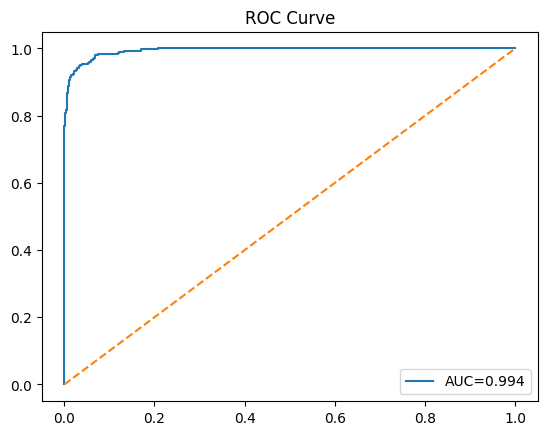

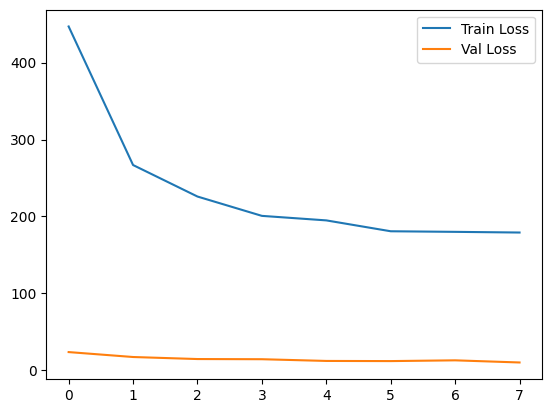

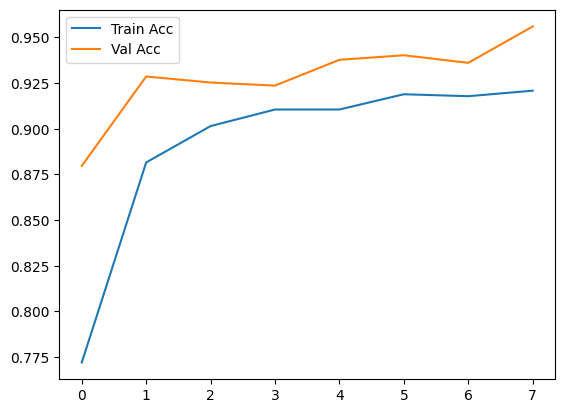

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ DONE


In [ ]:
# ===================== COMPLETE FINAL PIPELINE =====================

!pip -q install scikit-learn matplotlib kagglehub

import os, random, json
from collections import Counter
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import kagglehub

# ---------------- CONFIG ----------------
SOIL_DIR = "/content/soil_dataset/Soil types"   # upload your dataset
PLANT_DIR = "/content/plant_dataset/PlantVillage"                # ensure exists
EPOCHS = 8
BATCH = 16
LR = 1e-4
IGNORE = -1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- LABELS ----------------
SOIL_MAP = {"clay":0,"sandy":1,"loamy":2,"black":3,"red":4,"alluvial":5}
SOIL_NAMES = ["Clay","Sandy","Loamy","Black","Red","Alluvial"]
COND_NAMES = ["Healthy","Unhealthy"]
DIS_NAMES  = ["Healthy","Diseased"]

# ---------------- LOAD FIRST DATASET ----------------
samples = []

for soil_type in os.listdir(SOIL_DIR):
    folder = os.path.join(SOIL_DIR, soil_type)
    if not os.path.isdir(folder): continue

    name = soil_type.lower().strip()
    if name not in SOIL_MAP: continue

    label = SOIL_MAP[name]

    for img in os.listdir(folder):
        if img.lower().endswith((".jpg",".png",".jpeg")):
            samples.append([os.path.join(folder,img), label, 0, 0])

print("✅ Soil dataset loaded:", len(samples))

# ---------------- LOAD SECOND DATASET ----------------
print("Downloading second dataset...")
soil2_path = kagglehub.dataset_download("ai4a-lab/comprehensive-soil-classification-datasets")
print("Second dataset path:", soil2_path)

added = 0
for root, dirs, files in os.walk(soil2_path):
    fname = os.path.basename(root).lower()

    soil_idx = None
    for key in SOIL_MAP:
        if key in fname:
            soil_idx = SOIL_MAP[key]
            break

    if soil_idx is None:
        continue

    for f in files:
        if f.lower().endswith((".jpg",".png",".jpeg")):
            samples.append([os.path.join(root,f), soil_idx, 0, 0])
            added += 1

print("✅ Added from second dataset:", added)

# ---------------- LOAD PLANT DATA ----------------
for root, dirs, _ in os.walk(PLANT_DIR):
    for d in dirs:
        if "___" in d:
            cond = 0 if "healthy" in d.lower() else 1
            path = os.path.join(root,d)

            for img in os.listdir(path):
                if img.lower().endswith((".jpg",".png",".jpeg")):
                    samples.append([os.path.join(path,img), IGNORE, cond, cond])

print("✅ Total samples:", len(samples))

# ---------------- CHECK DISTRIBUTION ----------------
cnt = Counter([s[1] for s in samples if s[1] != IGNORE])
print("\n🌱 SOIL DISTRIBUTION:")
for i,n in enumerate(SOIL_NAMES):
    print(n, ":", cnt.get(i,0))

# ---------------- SPLIT ----------------
def strat_label(s): return s[1] if s[1]!=IGNORE else 0
labels = [strat_label(s) for s in samples]

train, temp = train_test_split(samples, test_size=0.3, stratify=labels)
temp_labels = [strat_label(s) for s in temp]
val, test = train_test_split(temp, test_size=0.5, stratify=temp_labels)

# ---------------- DATASET ----------------
transform = T.Compose([
    T.Resize((256,256)),
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(0.3,0.3,0.3,0.1),
    T.ToTensor()
])

class MyData(Dataset):
    def __init__(self,data): self.data=data
    def __len__(self): return len(self.data)
    def __getitem__(self,i):
        p,s,c,d = self.data[i]
        img = Image.open(p).convert("RGB")
        img = transform(img)
        return img, torch.tensor(s), torch.tensor(c), torch.tensor(d)

train_loader = DataLoader(MyData(train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(MyData(val), batch_size=BATCH)
test_loader  = DataLoader(MyData(test), batch_size=BATCH)

# ---------------- MODEL ----------------
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V1")
        for p in base.parameters(): p.requires_grad=False

        self.features = nn.Sequential(*list(base.children())[:-1])
        self.embed = nn.Sequential(nn.Linear(2048,256), nn.ReLU(), nn.Dropout(0.7))
        self.soil = nn.Linear(256,6)
        self.dis  = nn.Linear(256,2)

    def forward(self,x):
        f = self.features(x).view(x.size(0),-1)
        f = self.embed(f)
        return self.soil(f), self.dis(f)

model = Model().to(DEVICE)

# ---------------- TRAIN ----------------
loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=LR)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for ep in range(EPOCHS):
    model.train()
    tl, correct, total = 0,0,0

    for x,s,c,d in train_loader:
        x,s,d = x.to(DEVICE),s.to(DEVICE),d.to(DEVICE)

        ps,pd = model(x)
        loss = loss_fn(pd,d)

        mask = s!=-1
        if mask.sum()>0:
            loss += loss_fn(ps[mask],s[mask])

        opt.zero_grad(); loss.backward(); opt.step()

        tl += loss.item()
        pred = pd.argmax(1)
        correct += (pred==d).sum().item()
        total += d.size(0)

    train_acc = correct/total

    # validation
    model.eval()
    vc,vt,vl = 0,0,0
    with torch.no_grad():
        for x,_,_,d in val_loader:
            x,d = x.to(DEVICE),d.to(DEVICE)
            _,pd = model(x)
            vl += loss_fn(pd,d).item()
            vc += (pd.argmax(1)==d).sum().item()
            vt += d.size(0)

    val_acc = vc/vt

    train_losses.append(tl)
    val_losses.append(vl)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {ep+1}/{EPOCHS} | Loss:{tl:.2f} | TrainAcc:{train_acc:.3f} | ValAcc:{val_acc:.3f}")

# ---------------- TEST ----------------
model.eval()
soil_t, soil_p, cond_t, cond_p, dis_t, dis_p, probs = [],[],[],[],[],[],[]

with torch.no_grad():
    for x,s,c,d in test_loader:
        x,s,c,d = x.to(DEVICE),s.to(DEVICE),c.to(DEVICE),d.to(DEVICE)
        ps,pd = model(x)

        prob = torch.softmax(pd,dim=1)[:,1]
        probs.extend(prob.cpu().numpy())

        mask = s!=-1
        if mask.sum()>0:
            soil_t.extend(s[mask].cpu().numpy())
            soil_p.extend(ps[mask].argmax(1).cpu().numpy())

        cond_t.extend(c.cpu().numpy())
        cond_p.extend(pd.argmax(1).cpu().numpy())
        dis_t.extend(d.cpu().numpy())
        dis_p.extend(pd.argmax(1).cpu().numpy())

# ---------------- REPORTS ----------------
print("\n🌱 SOIL REPORT")
print(classification_report(soil_t, soil_p, labels=list(range(6)), target_names=SOIL_NAMES))

print("\n🌾 CONDITION REPORT")
print(classification_report(cond_t, cond_p, target_names=COND_NAMES))

print("\n🍃 DISEASE REPORT")
print(classification_report(dis_t, dis_p, target_names=DIS_NAMES))

# ---------------- ROC CURVE ----------------
fpr, tpr, _ = roc_curve(dis_t, probs)
roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

# ---------------- TRAINING PLOTS ----------------
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Val Loss")
plt.legend(); plt.show()

plt.plot(train_accs,label="Train Acc")
plt.plot(val_accs,label="Val Acc")
plt.legend(); plt.show()

# ---------------- SAVE ----------------
torch.save(model.state_dict(),"soil_model.pt")
json.dump({"soil":SOIL_NAMES,"condition":COND_NAMES,"disease":DIS_NAMES},
          open("soil_labels.json","w"))

from google.colab import files
files.download("soil_model.pt")
files.download("soil_labels.json")

print("✅ DONE")